In [2]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from model.LeNet5 import LeNet
import numpy as np
import torch
from PIL import Image, ImageOps
from torchvision import transforms


In [47]:
data, header = nrrd.read(r"D:\Project\ACL\my_tool\Thuan dot 1\KHUAT THI THU HANG (22940170)\8 t2_tse_sag.nrrd")
print(f"Data shape: {data.shape}")
seg_data,seg_header=nrrd.read(r"D:\Project\ACL\my_tool\Thuan dot 1\KHUAT THI THU HANG (22940170)\Segmentation.seg.nrrd")
print(f"segment data shape: {seg_data.shape}")
# result = {k: v for k, v in seg_header.items() if k.startswith("Segment")}
# for i in range(len(result)):
#     print(f'Key :{list(result.keys())[i]} - Value: {list(result.values())[i]}')

Data shape: (608, 608, 25)
segment data shape: (608, 608, 25)


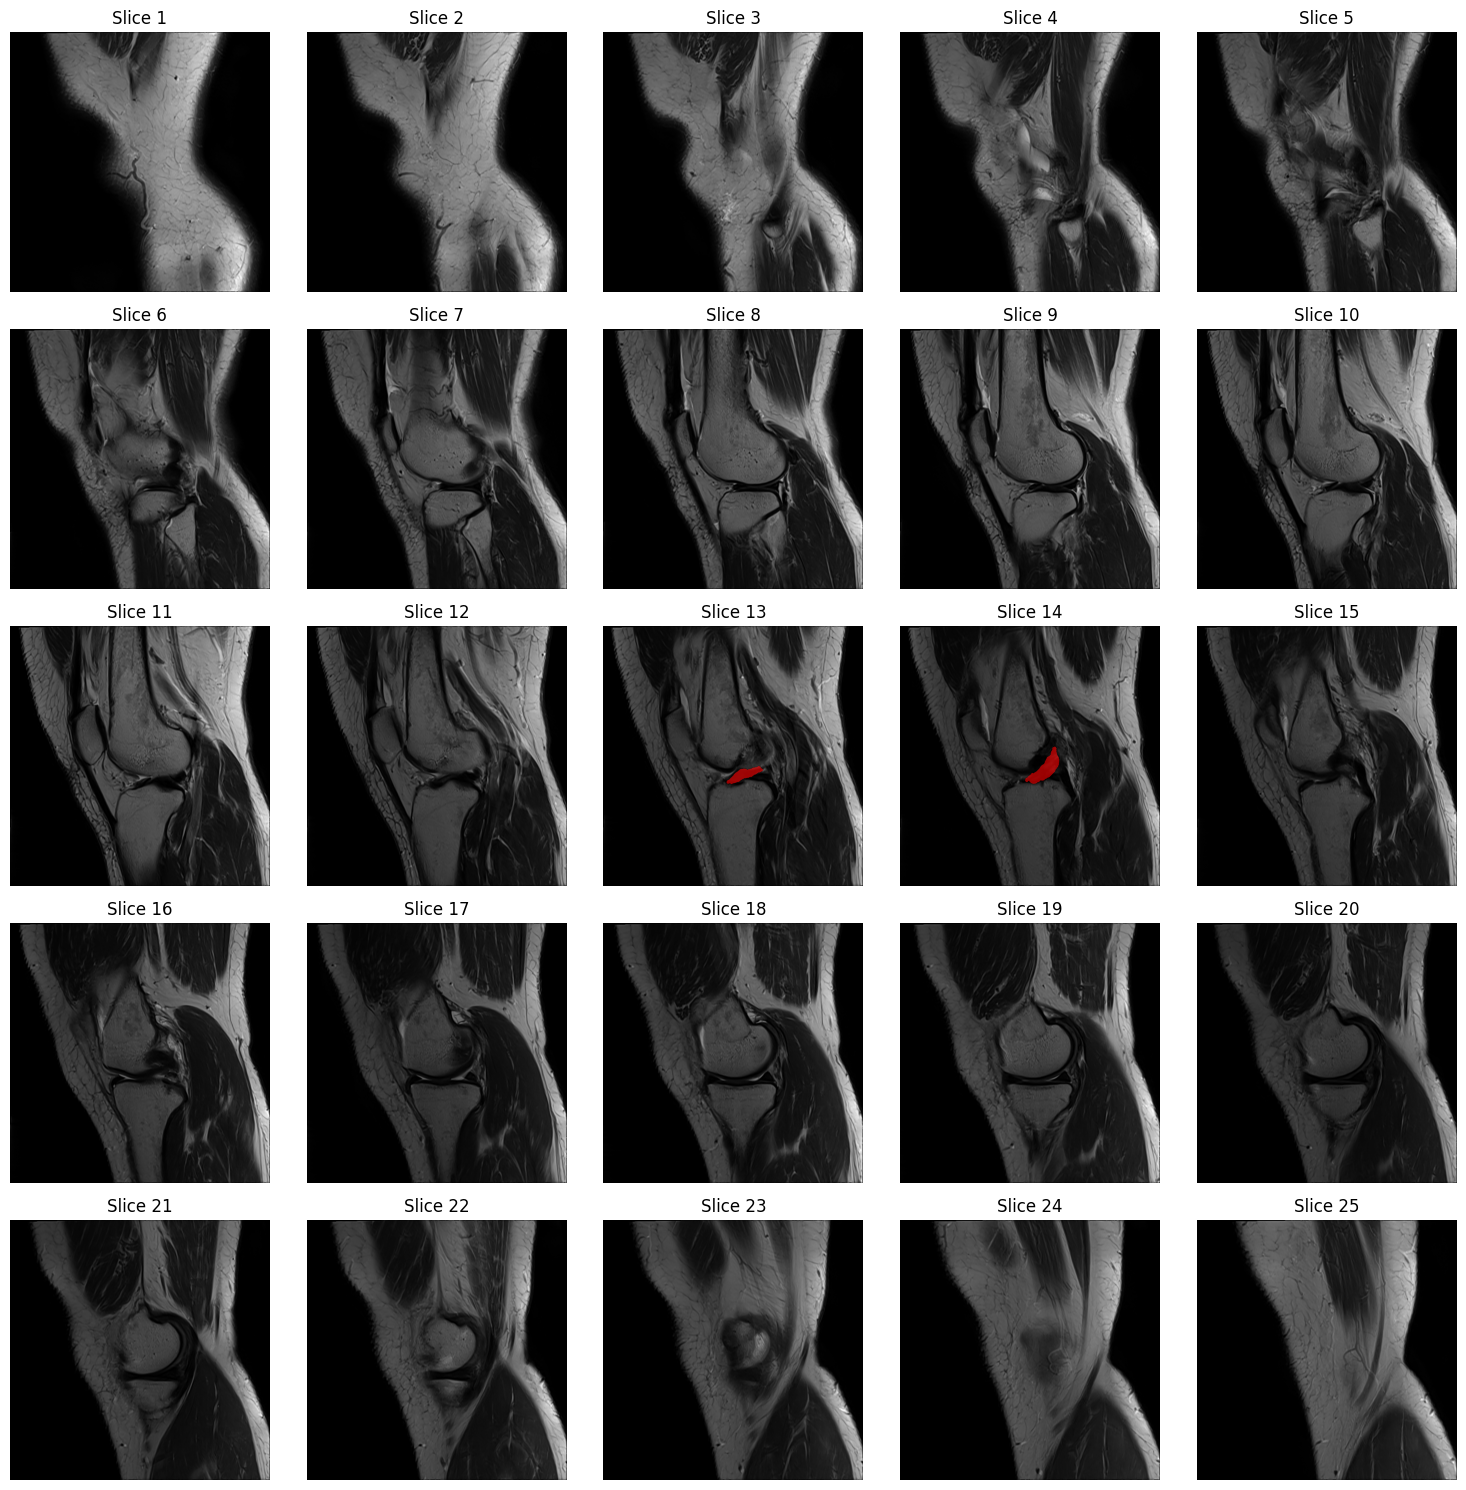

In [48]:
def flip_image(img):
    rotated_image = np.rot90(img, k=3)
    flipped_image = np.fliplr(rotated_image)
    return flipped_image    
    
cmap = ListedColormap([
    (0, 0, 0, 0),       # class 0 → transparent
    (1, 0, 0, 0.6),     # class 1 → red
    (1, 1, 0, 0.6),     # class 2 → green
    (1, 0, 0, 0.6)      # class 3 → yellow
])
n_shows = 25
cols = 5
rows = 5

plt.figure(figsize=(15,15))


for i in range(n_shows):
    img = data[:,:,i]
    label = seg_data[:,:,i]   # label must be integers 0–3
    flip_img=flip_image(img)
    flip_label=flip_image(label)
    plt.subplot(rows, cols, i + 1)
    plt.title(f"Slice {i+1}")
    plt.imshow(flip_img, cmap="gray")       # clear grayscale
    plt.imshow(flip_label, cmap=cmap)       # crisp segmentation overlay
    plt.axis("off")
plt.tight_layout()
plt.show()

In [36]:
para = {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':2,
        'number_of_fc_layer':2,
        'num_classes':2,
        'conv_channels': [6, 16],
        'fc_feature':[84,2]
    }
model=LeNet(para)

In [90]:

def transform_image(image_np, target_size):
    """
    image_np: 2D numpy array (H, W), dtype can be uint16
    target_size: (H_out, W_out)
    returns: torch.Tensor, shape (1, H_out, W_out), values in [0, 1]
    """
    # 1) Convert to float32 and normalize to 0–1
    image_np = image_np.astype(np.float32)
    min_val = image_np.min()
    max_val = image_np.max()
    image_np = (image_np - min_val) / (max_val - min_val + 1e-8)  # now in [0, 1]
    # 2) Convert to uint8 for PIL (0–255)
    image_uint8 = (image_np * 255).astype(np.uint8)

    # 3) To PIL image
    img = Image.fromarray(image_uint8)   # mode 'L' (grayscale)

    # 4) Geometric transforms
    img = img.rotate(90, expand=True)   # rotate 270°
    img = ImageOps.flip(img)             # vertical flip
    # If you want horizontal flip instead:
    # img = ImageOps.mirror(img)

    # 5) Resize + to tensor (values back to [0, 1])
    preprocess = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),   # -> (1, H, W), values in [0, 1]
    ])

    tensor = preprocess(img)
    return tensor, img


In [91]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.load_state_dict(torch.load('model.pth',weights_only=True))
model.to(device)
model.eval()

Using device: cuda


LeNet(
  (Conv_layer): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 6, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(6, 16, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (FC_layer): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=97344, out_features=84, bias=True)
      (1): ReLU()
      (2): Linear(in_features=84, out_features=2, bias=True)
      (3): Softmax(dim=1)
    )
  )
)

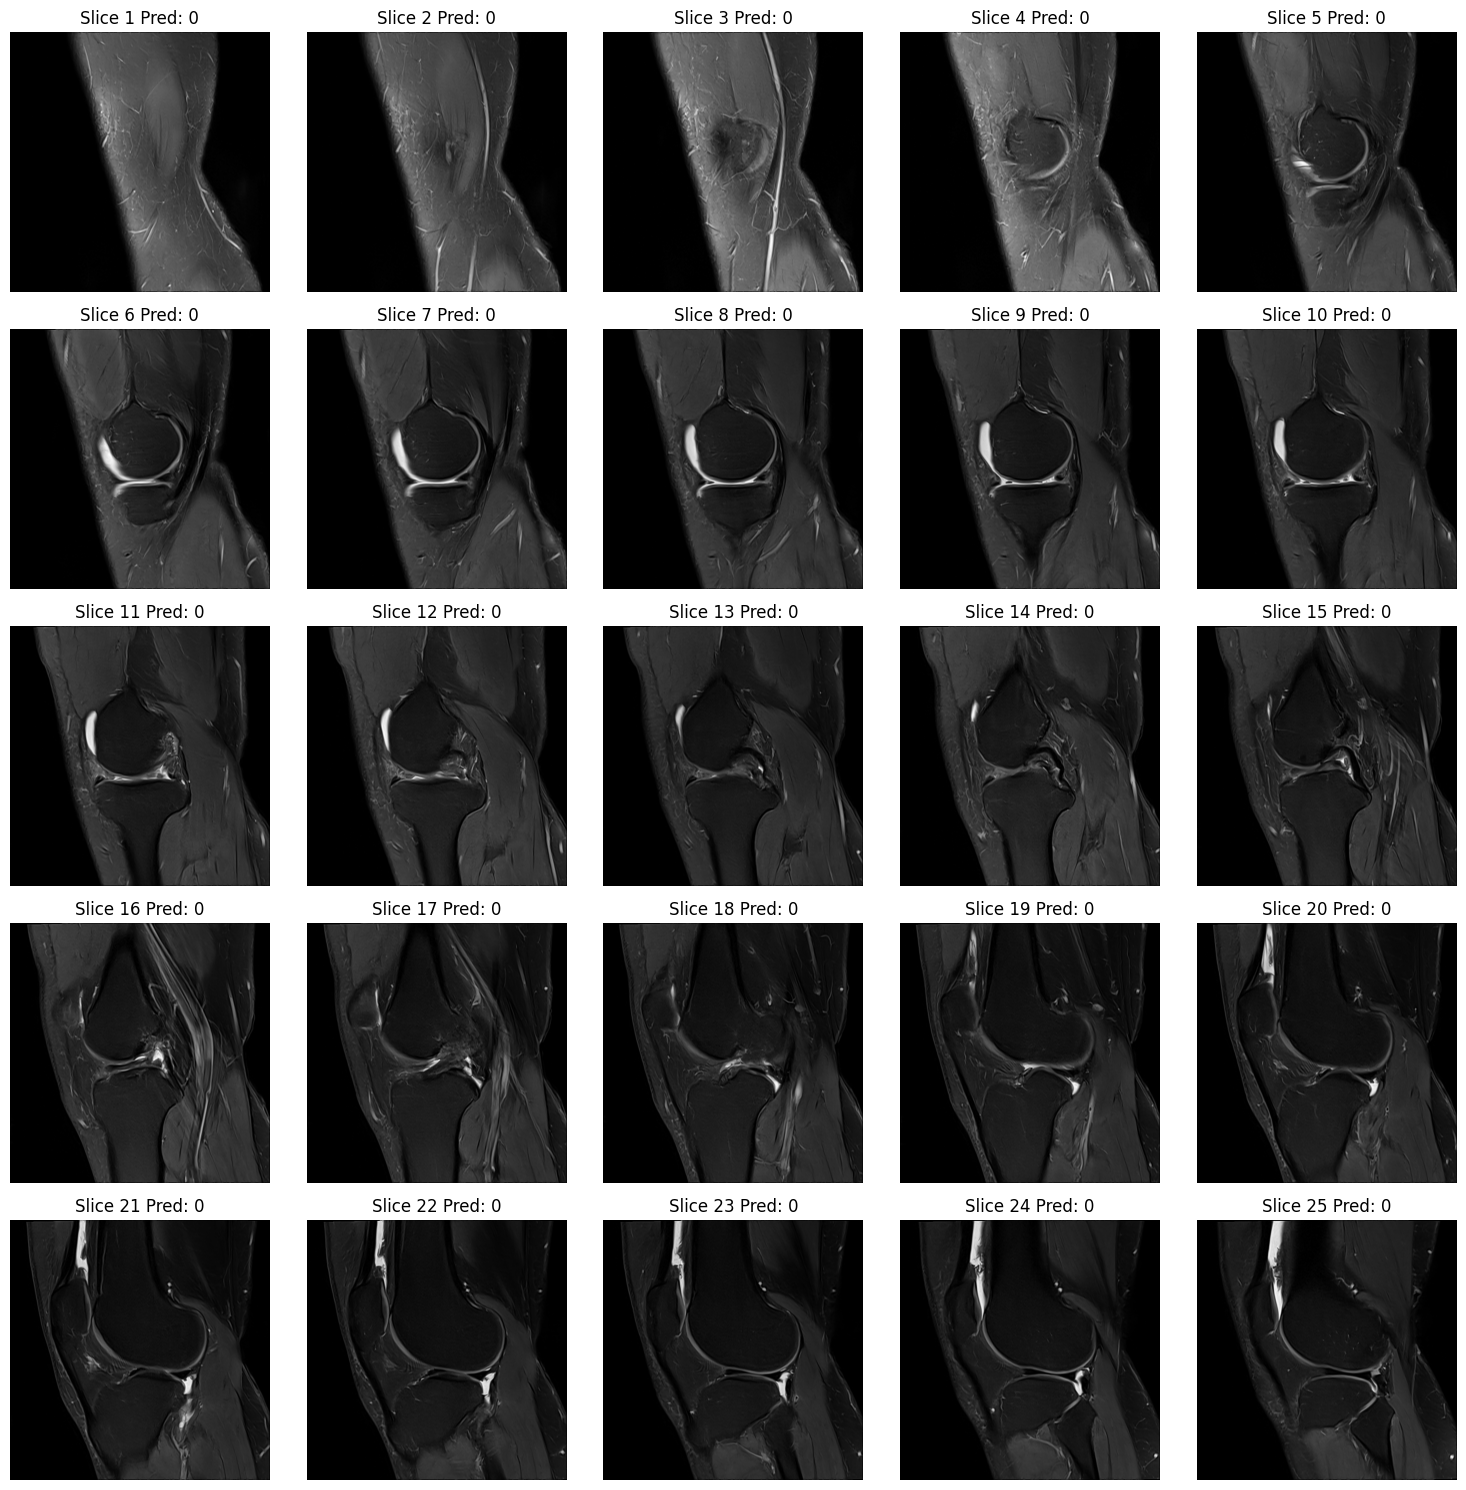

In [92]:
predictions = []
images_for_plot = []
with torch.no_grad():
    for i in range(25):
        slice_np = data[:, :, i]   # uint16 slice

        input_tensor, img_for_plot = transform_image(slice_np, (320, 320))
        images_for_plot.append(img_for_plot)     # keep for visualization
        input_tensor = input_tensor.unsqueeze(0).to(device)  # (1, 1, H, W)
        logits = model(input_tensor)             # model prediction
        pred_label = torch.argmax(logits, dim=1).item()
        predictions.append(pred_label)


# -----------------------------
# Plot (5×5 matrix)
# -----------------------------
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
idx = 0
for r in range(5):
    for c in range(5):
        axes[r, c].imshow(images_for_plot[idx], cmap='gray')
        axes[r, c].set_title(f"Slice {idx+1} Pred: {predictions[idx]}")
        axes[r, c].axis("off")
        idx += 1

plt.tight_layout()
plt.show()

In [ ]:
List[dict{'Volume_data': data,
          'Segmentation_data': seg_data,
          'Chan doan': 0 -> 5 }]